# ⁉️ <b>EDA & Statistical Analysis</b>
1) <b>Highest Performing Products</b>
2) <b>Highest Performing Cities</b>
3) <b>Sales Overtime</b>
4) <b>Customer Insights</b>
5) <b>Shipping Insights</b>
6) <br>
7) <br>

This notebook explains key concepts used in the .. class<br>
<i>superstore -> utilities</i> 

## <b>Highest Performing Products</b>

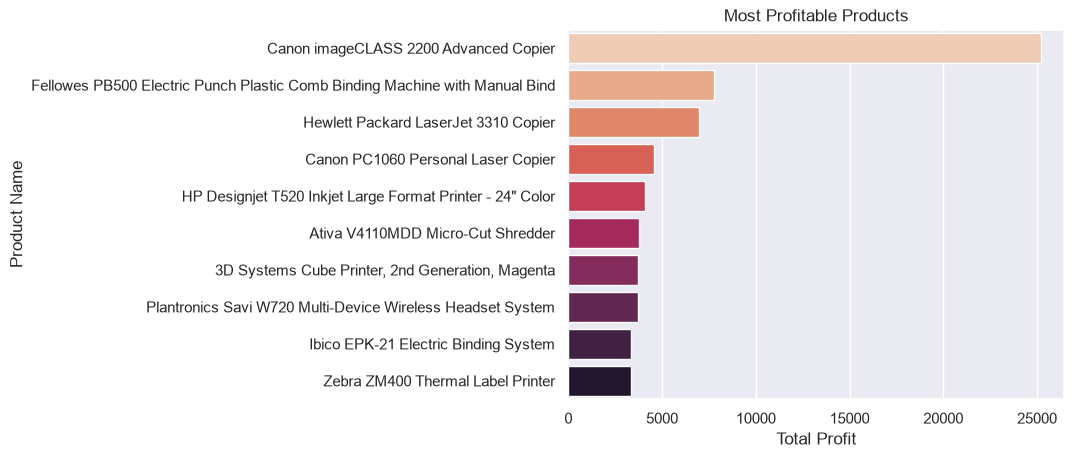

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from superstore.utilities import Cleaner, FeatureEngineering

try:
    df = pd.read_excel("../Superstore 2019.xls", index_col="Row ID")
except FileNotFoundError:
    print("Change file name to Superstore 2019.xls")

cleaner = Cleaner(df)
df = cleaner.clean()
fe = FeatureEngineering(df)
df = fe.add_columns()

sns.set_theme() 
palette = sns.color_palette("rocket_r", n_colors=10)
sns.set_palette(palette)

most_profitable_products = (
    df.groupby("Product Name", as_index=False)["Profit"]
    .sum()
    .sort_values("Profit", ascending=False)
    .head(10)
)

sns.barplot(data=most_profitable_products, x="Profit", y="Product Name", orient="h", hue="Product Name", palette=palette)
plt.title("Most Profitable Products")
plt.xlabel("Total Profit")
plt.show()


#Canon imageCLASS MF4450 is the most profitable product.

In [2]:
most_profitable_product_filter = df["Product Name"] == "Canon imageCLASS 2200 Advanced Copier"

"""
This product has a very high profit margin of 48%
Most of the high-profit products are copiers/printers that have high-profit margins.
"""

df[most_profitable_product_filter][["Quantity", "Order Date", "Sales", "Profit", "Discount", "Profit Margin"]].sort_values("Order Date")

,Quantity,Order Date,Sales,Profit,Discount,Profit Margin
Row ID,,,,,,
6426,4,2018-05-23,8399.976,1119.9968,0.4,0.13
6827,5,2018-10-02,17499.950,8399.9760,0.0,0.48
8154,4,2019-03-23,13999.960,6719.9808,0.0,0.48
2624,4,2019-10-22,11199.968,3919.9888,0.2,0.35
4191,3,2019-11-17,10499.970,5039.9856,0.0,0.48


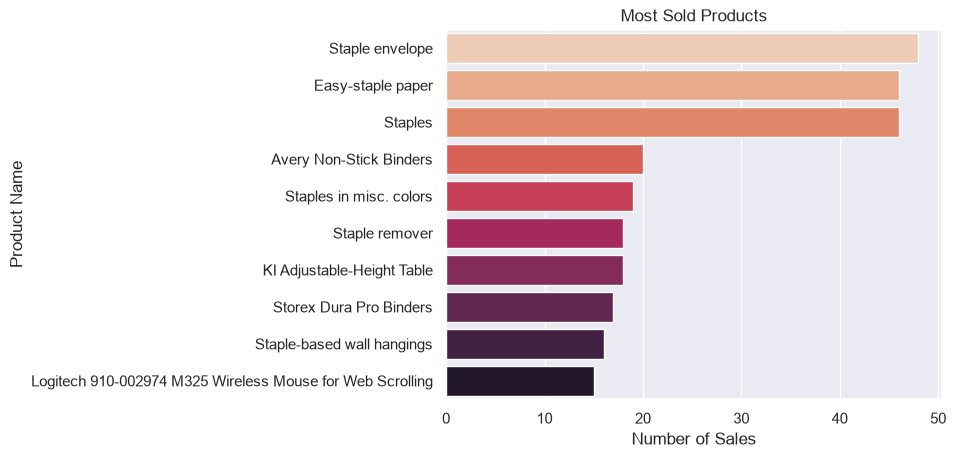

In [3]:
most_sold = df["Product Name"].value_counts().head(10).reset_index()
sns.barplot(most_sold, x="count", y="Product Name", hue="Product Name", palette=palette)
plt.title("Most Sold Products")
plt.xlabel("Number of Sales")
plt.show()

#Staple envelops are the most sold product.

## <b>Highest Performing Cities</b>

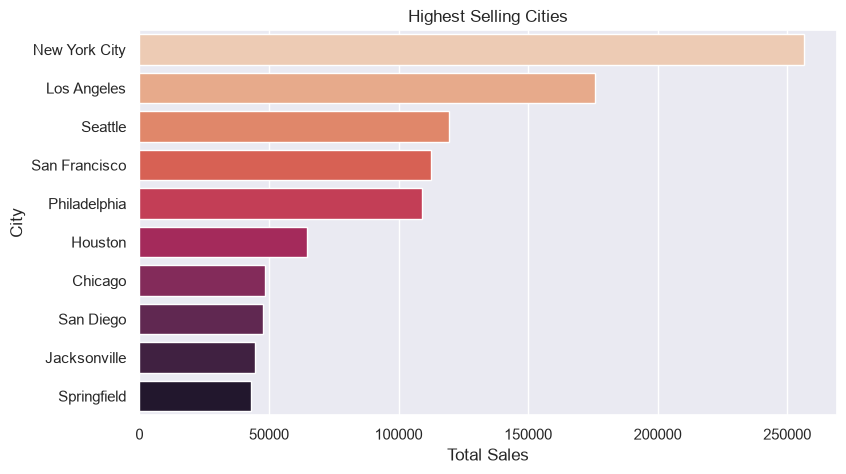

In [4]:
highest_selling_cities = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()  
)

plt.figure(figsize=(9, 5))
sns.barplot(data=highest_selling_cities, x="Sales", y="City", orient="h", hue="City", palette=palette)
plt.title("Highest Selling Cities")
plt.xlabel("Total Sales")
plt.show()
#The highest selling city is New York City.

## <b>Sales Overtime</b>

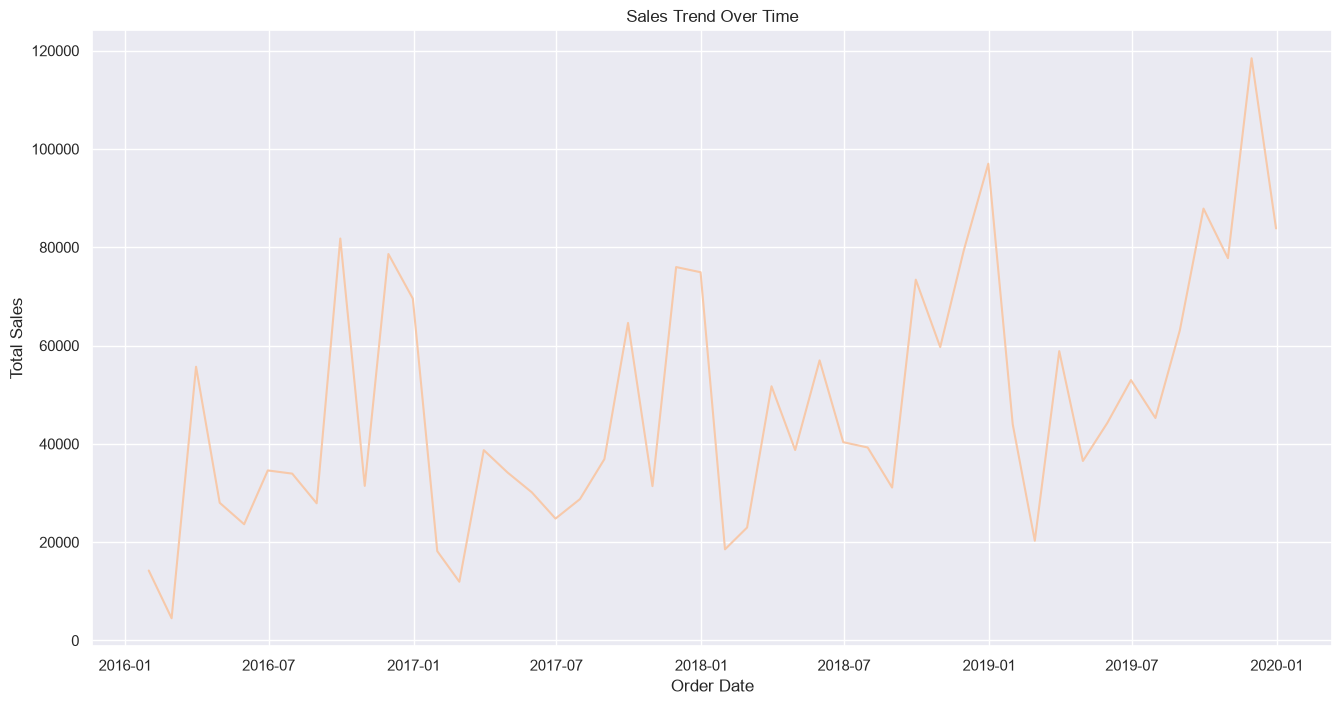

In [5]:
sales_change = (
    df.resample('ME', on='Order Date')['Sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(16, 8))
sns.lineplot(data=sales_change, x="Order Date", y="Sales")
plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.show()

In [48]:
"""
There's a pattern of highest sales for the months of September, November, and December. 
This is likely due to the holiday season, back-to-school shopping, and black Friday sales. 
There's an obvious drop in sales in January and February, which is likely due to these seasons ending
"""

sales_change.sort_values(by="Sales", ascending=False).head(10)

,Order Date,Sales
46,2019-11-30,118447.8250
35,2018-12-31,96999.0430
44,2019-09-30,87866.6520
47,2019-12-31,83829.3188
8,2016-09-30,81777.3508
34,2018-11-30,79411.9658
10,2016-11-30,78628.7167
45,2019-10-31,77776.9232
22,2017-11-30,75972.5635
23,2017-12-31,74919.5212


## <b>Customer Insights</b>

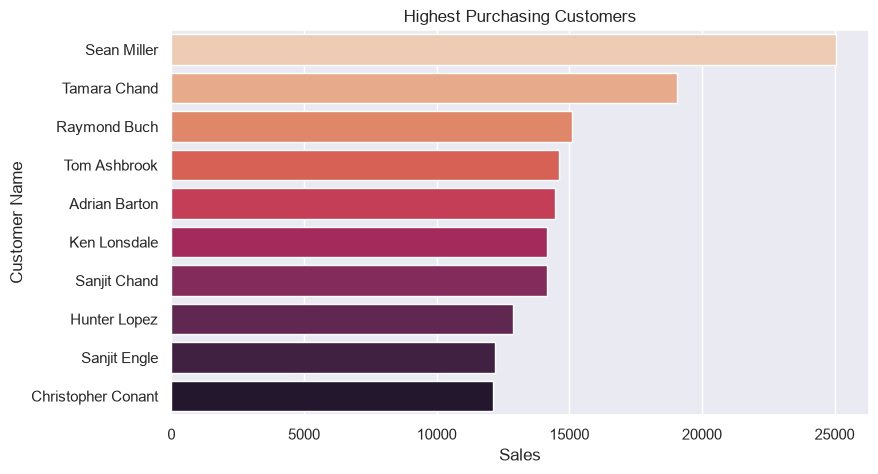

In [7]:
highest_selling_customers = (
    df.groupby(["Customer ID", "Customer Name"])["Sales"].sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()  
)

plt.figure(figsize=(9, 5))
sns.barplot(data=highest_selling_customers, x="Sales", y="Customer Name", orient="h", hue="Customer Name", palette=palette)
plt.title("Highest Purchasing Customers")
plt.xlabel("Sales")
plt.show()


In [8]:
top_customer_filter = df["Customer Name"] == "Sean Miller"
df[top_customer_filter].sort_values("Order Date")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration,Sales Performance Category
Row ID,,,,,,,,,,,,,,,,,,,,,
2697,CA-2016-145317,2016-03-18,2016-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,Technology,Machines,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,821.300,4,0.5,-16.4260,-0.02,5 days,Very High
2698,CA-2016-145317,2016-03-18,2016-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784,-0.08,5 days,Very High
2699,CA-2016-145317,2016-03-18,2016-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,Office Supplies,Paper,Xerox 195,21.376,4,0.2,7.4816,0.35,5 days,Medium
2700,CA-2016-145317,2016-03-18,2016-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,Office Supplies,Art,Avery Fluorescent Highlighter Four-Color Set,8.016,3,0.2,1.0020,0.12,5 days,Low
2701,CA-2016-145317,2016-03-18,2016-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,Furniture,Furnishings,"Executive Impressions 13"" Clairmont Wall Clock",30.768,2,0.2,8.0766,0.26,5 days,Medium
2702,CA-2016-145317,2016-03-18,2016-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,Office Supplies,Fasteners,Staples,18.936,3,0.2,5.9175,0.31,5 days,Medium
2703,CA-2016-145317,2016-03-18,2016-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,...,Furniture,Furnishings,"Dana Fluorescent Magnifying Lamp, White, 36""",122.352,3,0.2,15.2940,0.12,5 days,High
9188,US-2017-130512,2017-08-21,2017-08-25,Standard Class,SM-20320,Sean Miller,Home Office,United States,Allentown,Pennsylvania,...,Office Supplies,Supplies,Staple remover,3.488,2,0.2,-0.6976,-0.20,4 days,Low
9189,US-2017-130512,2017-08-21,2017-08-25,Standard Class,SM-20320,Sean Miller,Home Office,United States,Allentown,Pennsylvania,...,Technology,Accessories,Sabrent 4-Port USB 2.0 Hub,21.728,4,0.2,3.8024,0.18,4 days,Medium


In [9]:
customer_for_many_years = int((df[top_customer_filter]["Order Date"].max() - df[top_customer_filter]["Order Date"].min()).days)
cities = df[top_customer_filter]["City"].value_counts().count()
print(f"Sean Miller has been a customer for {customer_for_many_years} days and has purchased from {cities} different cities.")

Sean Miller has been a customer for 1303 days and has purchased from 5 different cities.


## <b>Shipping Insights</b>

Most Used Shipping Method

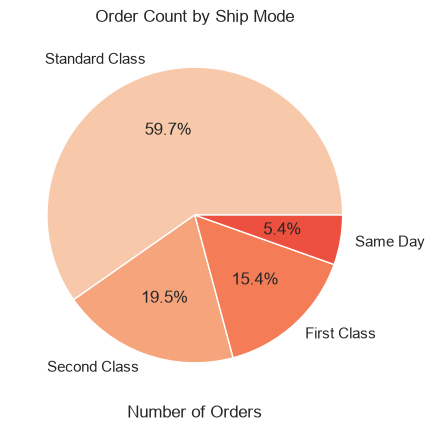

In [46]:
plt.pie(data=df["Ship Mode"].value_counts().reset_index(), labels="Ship Mode", autopct="%1.1f%%", x="count")
plt.title("Order Count by Ship Mode")
plt.xlabel("Number of Orders")
plt.show()

#Standard Class is the most used shipping method

Further Analysis & Insights

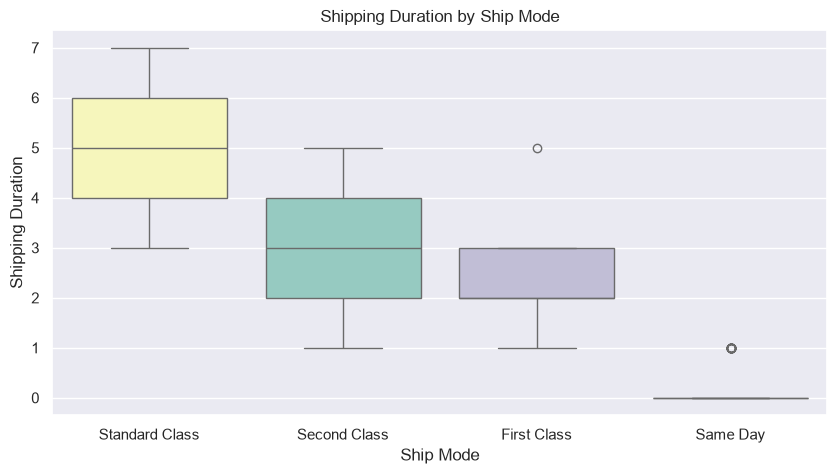

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Ship Mode", y="Shipping Duration", hue="Ship Mode", palette="Set3", order=["Standard Class", "Second Class", "First Class", "Same Day"])
plt.title("Shipping Duration by Ship Mode")
plt.show()

In [ ]:
"""
Standard Class
-Shipping takes 3 to 7 days

Data looks fine overall
"""

standard_class_shipping = df[df["Ship Mode"] == "Standard Class"]
standard_class_shipping.describe()


,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration
count,5967,5967,5967.0,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000,5967.000000
mean,2018-04-17 15:25:14.932126,2018-04-22 15:34:54.117647,54946.398693,227.574052,3.820178,0.160000,27.501399,0.109789,5.006704
min,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.0,0.444000,1.000000,0.000000,-6599.978000,-2.750000,3.000000
25%,2017-04-29 00:00:00,2017-05-04 00:00:00,22304.0,16.778000,2.000000,0.000000,1.470700,0.060000,4.000000
50%,2018-06-05 00:00:00,2018-06-09 00:00:00,55407.0,52.760000,3.000000,0.200000,8.302800,0.270000,5.000000
75%,2019-05-03 00:00:00,2019-05-07 12:00:00,90004.0,209.910000,5.000000,0.200000,28.767600,0.360000,6.000000
max,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.0,22638.480000,14.000000,0.800000,8399.976000,0.500000,7.000000
std,NaN,NaN,31977.807178,646.792823,2.246764,0.210792,250.030971,0.482504,1.011311


In [74]:
"""
Second Class
-Shipping takes 1 to 5 days

Data looks fine overall
"""

first_class_shipping = df[df["Ship Mode"] == "First Class"]
first_class_shipping.describe()


,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration
count,1538,1538,1538.0,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000,1538.000000
mean,2018-05-31 14:27:55.942782,2018-06-02 18:51:01.638491,54765.611834,228.497024,3.701560,0.164610,31.839948,0.115670,2.182705
min,2016-01-06 00:00:00,2016-01-07 00:00:00,1810.0,0.984000,1.000000,0.000000,-2639.991200,-2.700000,1.000000
25%,2017-06-16 12:00:00,2017-06-19 06:00:00,21215.0,18.164000,2.000000,0.000000,1.791450,0.070000,2.000000
50%,2018-08-30 00:00:00,2018-09-01 00:00:00,60016.0,54.940000,3.000000,0.200000,8.778900,0.270000,2.000000
75%,2019-06-10 00:00:00,2019-06-12 00:00:00,90008.0,199.980000,5.000000,0.200000,28.831950,0.360000,3.000000
max,2019-12-29 00:00:00,2019-12-31 00:00:00,99207.0,13999.960000,14.000000,0.800000,6719.980800,0.500000,5.000000
std,NaN,NaN,32766.644358,630.384710,2.119098,0.210319,257.794233,0.458159,0.775210


In [77]:
"""
First Class
-Shipping takes 1 to 3 days

Outliers are present
"""

first_class_shipping = df[df["Ship Mode"] == "First Class"]
shipping_filter = (first_class_shipping["Shipping Duration"] == 5)
first_class_shipping[shipping_filter]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration,Sales Performance Category
Row ID,,,,,,,,,,,,,,,,,,,,,
9464,CA-2016-156545,2016-02-27,2016-03-03,First Class,JS-16030,Joy Smith,Consumer,United States,Columbus,Ohio,...,Office Supplies,Art,Zebra Zazzle Fluorescent Highlighters,19.456,4,0.2,3.4048,0.17,5,Medium


In [78]:
"""
Same Day
-Shipping takes 0days

Outliers are present
"""

same_day_shipping = df[df["Ship Mode"] == "Same Day"]
shipping_filter = (same_day_shipping["Shipping Duration"] == 1)
same_day_shipping[shipping_filter]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Shipping Duration,Sales Performance Category
Row ID,,,,,,,,,,,,,,,,,,,,,
1474,US-2017-105676,2017-12-01,2017-12-02,Same Day,NM-18520,Neoma Murray,Consumer,United States,Houston,Texas,...,Furniture,Furnishings,"Eldon Image Series Desk Accessories, Burgundy",6.688,4,0.6,-4.0128,-0.60,1,Low
2349,CA-2019-109701,2019-12-02,2019-12-03,Same Day,AM-10360,Alice McCarthy,Corporate,United States,Los Angeles,California,...,Office Supplies,Binders,3-ring staple pack,9.024,6,0.2,3.1584,0.35,1,Low
2350,CA-2019-109701,2019-12-02,2019-12-03,Same Day,AM-10360,Alice McCarthy,Corporate,United States,Los Angeles,California,...,Office Supplies,Binders,Satellite Sectional Post Binders,69.456,2,0.2,22.5732,0.32,1,High
2351,CA-2019-109701,2019-12-02,2019-12-03,Same Day,AM-10360,Alice McCarthy,Corporate,United States,Los Angeles,California,...,Office Supplies,Paper,"Wirebound Message Book, 4 per Page",10.860,2,0.0,5.3214,0.49,1,Low
2352,CA-2019-109701,2019-12-02,2019-12-03,Same Day,AM-10360,Alice McCarthy,Corporate,United States,Los Angeles,California,...,Office Supplies,Appliances,Fellowes Advanced Computer Series Surge Protec...,79.470,3,0.0,22.2516,0.28,1,High
2353,CA-2019-109701,2019-12-02,2019-12-03,Same Day,AM-10360,Alice McCarthy,Corporate,United States,Los Angeles,California,...,Office Supplies,Art,Prang Dustless Chalk Sticks,10.080,6,0.0,5.0400,0.50,1,Low
3042,CA-2019-149559,2019-09-11,2019-09-12,Same Day,KF-16285,Karen Ferguson,Home Office,United States,Long Beach,California,...,Office Supplies,Paper,Xerox 1996,12.960,2,0.0,6.2208,0.48,1,Low
3043,CA-2019-149559,2019-09-11,2019-09-12,Same Day,KF-16285,Karen Ferguson,Home Office,United States,Long Beach,California,...,Office Supplies,Envelopes,#10 Self-Seal White Envelopes,22.180,2,0.0,10.8682,0.49,1,Medium
3044,CA-2019-149559,2019-09-11,2019-09-12,Same Day,KF-16285,Karen Ferguson,Home Office,United States,Long Beach,California,...,Furniture,Chairs,Hon Pagoda Stacking Chairs,2054.272,8,0.2,256.7840,0.12,1,Very High


## <b>How are Sales/Profit distributed across orders?</b>

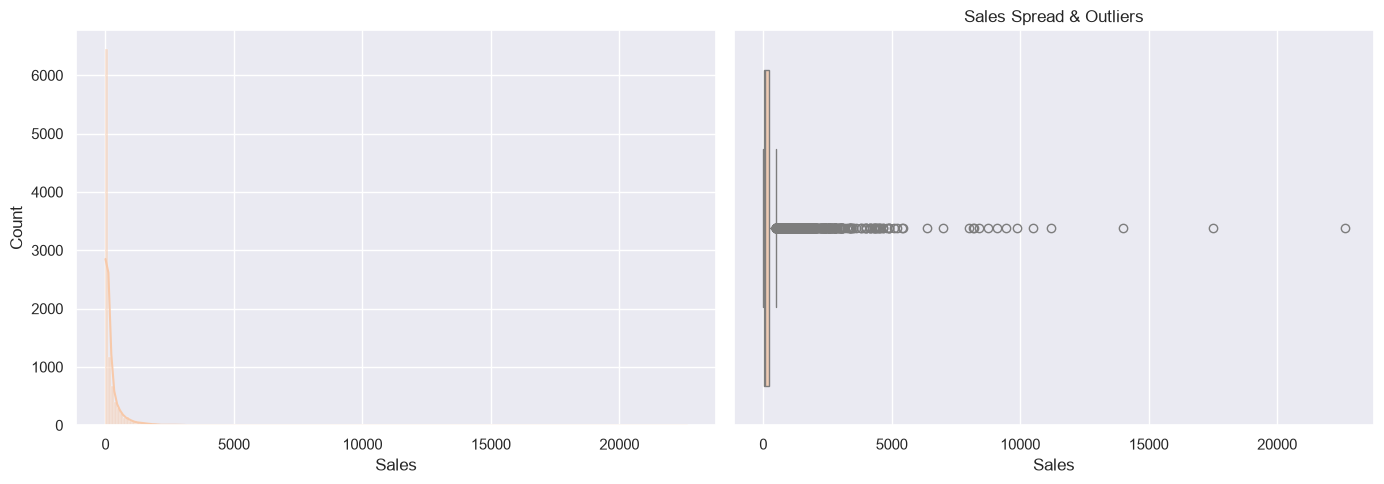

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="Sales", kde=True, ax=axes[0])
plt.title("Sales Distribution")

sns.boxplot(data=df, x="Sales")
plt.title("Sales Spread & Outliers")

plt.tight_layout()
plt.show()

## <b>Is there a correlation between quantity and discounts?</b>

Correlation between Quantity and Discount: 0.009


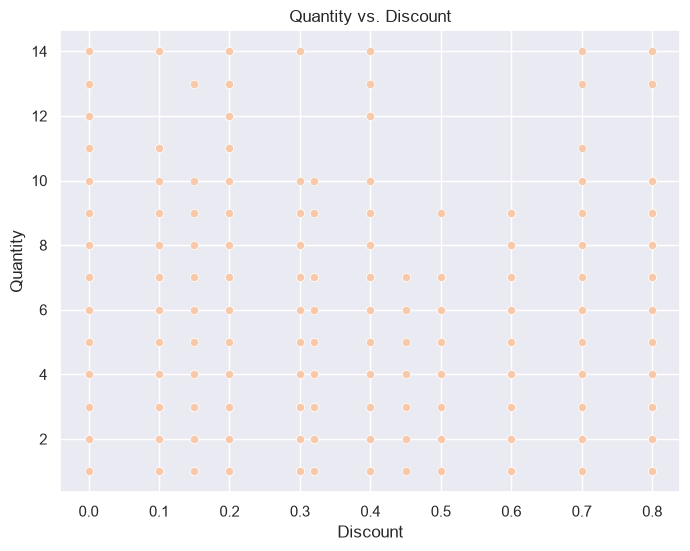

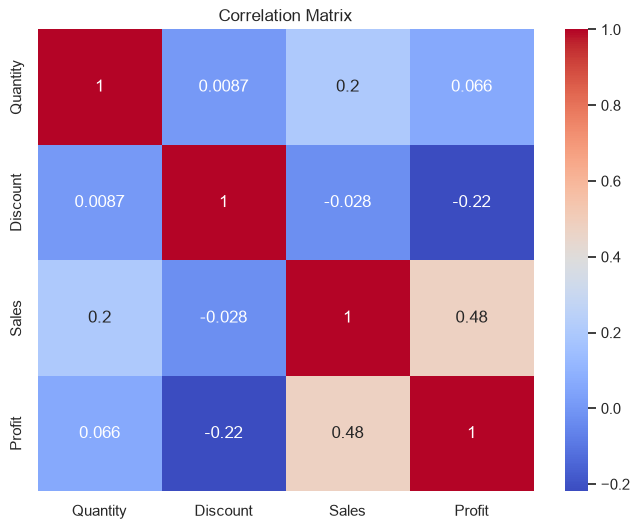

In [13]:
correlation = df["Quantity"].corr(df["Discount"])
print(f"Correlation between Quantity and Discount: {correlation:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Discount", y="Quantity")
plt.title("Quantity vs. Discount")
plt.show()

# Bonus: broader correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[["Quantity", "Discount", "Sales", "Profit"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()